##**General Introduction** <br>
As part of this code, I would be using a **supervised learning** technique to develop a model to predict positive market moves (uptrend) using the the daily returns as the key driver of the target variable. <br> <br>
This model will consider binomial classification of returns as **0** for any returns below 0.25% and **1** for any returns equal to or above 0.25%. This will be the target variable in this model. <br> <br>
I will be using 5 years (start="2020-01-01", end="2025-01-01") of **S&P 500** index data downloaded from **yfinance** - yahoo finance python library (Ticker is "**^GSPC**") to calculate the daily returns. This 2020–2025 period covers several regimes, includes COVID crash, recovery and a bull market. The model can likely learn regime-specific patterns that don't generalize.I will be using the Close price. <br><br>
The type of **supervised learning** technique i will be using here to develop the model is an **Gradient Booting** technique and the specific type is **XGBOOST** (Extreme Gradient Boosting). <br> <br>

The model development will follow the below given 7 standard steps (this cell forms the part of 1st):

| Steps        | Workflow                  | Remarks                                                         |
|:-------------|:--------------------------|:----------------------------------------------------------------|
|Step 1        | Ideation                  | Define objective, success metrics     |
|Step 2        | Data Collection           | Gather and integrate data
|Step 3        | Exploratory Data Analysis (Initial) | Broad exploration: stats, distributions, correlations, missing data |
|Step 4        | Data Cleaning           | Handle missing values, outliers, duplicates.            |
|Step 5        | Feature Engineering & Transformation            | Feature creation, scaling, encoding, selection                         |
|        | Subset Validation EDA            | Re-examine chosen features: check distributions, multicollinearity, relationships                      |               
|Step 6        | Modeling                  | Select algorithm(s), train models, tune hyperparameters                           |
|Step 7        | Evaluation                   | Validate using metrics and backtesting       |

**Install Packages**

In [1]:
!pip install -q xgboost

**Import necessary libraries**

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Classifier
from xgboost import XGBClassifier

# Preprocessing
from sklearn.model_selection import (train_test_split,
                                    TimeSeriesSplit,
                                    RandomizedSearchCV,
                                    )

from sklearn.feature_selection import RFECV, SelectFromModel

from sklearn.utils.class_weight import compute_sample_weight


# Metrics
from sklearn.metrics import (accuracy_score,
                             balanced_accuracy_score,
                             RocCurveDisplay,
                             ConfusionMatrixDisplay,
                             PrecisionRecallDisplay,
                             classification_report
                            )


#Source Data
import yfinance as yf


**Data Collection**

The ticker '^GSPC' is used to donwload S&P 500 data from Yahoo finance. I am using the data of 5 years.

In [3]:
data = yf.download("^GSPC", start="2020-01-01", end="2025-01-01")
data.columns = data.columns.get_level_values(0)
data

/tmp/ipykernel_2455/929139019.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000
...,...,...,...,...,...
2024-12-24,6040.040039,6040.100098,5981.439941,5984.629883,1757720000
2024-12-26,6037.589844,6049.750000,6007.370117,6024.970215,2904530000
2024-12-27,5970.839844,6006.169922,5932.950195,6006.169922,3159610000


**Exploratory Data Analysis (Initial)**

In [4]:
data.isnull().sum() # To check for presence of null values as yahoo finance can give null values for holidays.

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1258 non-null   float64
 1   High    1258 non-null   float64
 2   Low     1258 non-null   float64
 3   Open    1258 non-null   float64
 4   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [6]:
data.describe() # To check for distribution of data.

Price,Close,High,Low,Open,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,4259.606933,4283.980701,4232.242692,4258.915009,4.376287e+09
std,767.448592,765.438426,769.613238,767.478053,1.052113e+09
min,2237.399902,2300.729980,2191.860107,2290.709961,0.000000e+00
25%,3819.052551,3846.012512,3791.585022,3817.265015,3.751010e+09
50%,4204.880127,4233.785156,4186.004883,4206.094971,4.113210e+09
75%,4603.890137,4631.122681,4579.504883,4602.849854,4.712908e+09
max,6090.270020,6099.970215,6079.979980,6089.029785,9.976520e+09


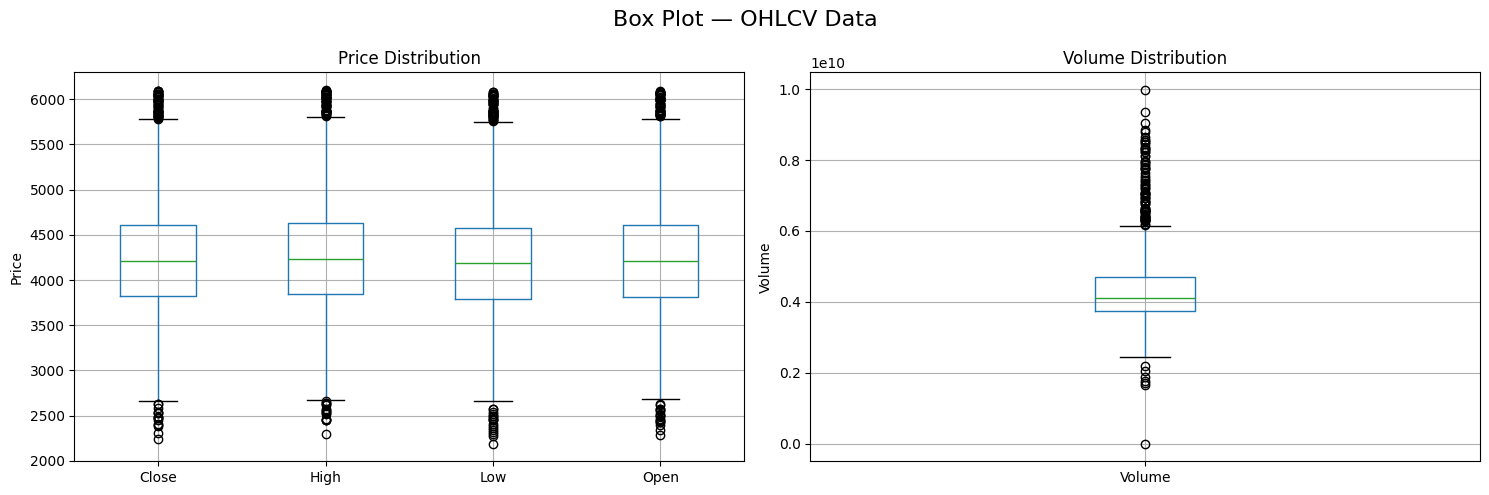

In [7]:
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Distribution for Price columns
data[['Close', 'High', 'Low', 'Open']].boxplot(ax = axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_ylabel('Price')

# Distribution for Volume separately (different scale)
data[['Volume']].boxplot(ax = axes[1])
axes[1].set_title('Volume Distribution')
axes[1].set_ylabel('Volume')

plt.suptitle('Box Plot — OHLCV Data', fontsize = 16)
plt.tight_layout()
plt.show()

In [8]:
print(data.duplicated().sum()) # To check for duplicate values.

0


**Data Cleaning**

I did the Intial EDA above, I can be seen that there are no null values. But even if there have been null values, XGBOOST algorithm can natively handle the missing values using the 'Sparsity Aware Split Finding'. For other techniques that cannot handle misssing values natively, we can drop rows with null values, or missing values can be filled using forward fill/ back fill techniques or missing values can also be filled with mean or median value. But it is important to note that for the timeseries data using mean or median value to fill a missing value can be more like a speed bump and therefore is unsuitable.
<br><br>
Also as the XGBOOST technqiue is a tree based model, we don't need to do scaling of data as the decision are made using the threshold splits on the relative values of feature variables so the absolute magnitude is irrelevant here. For the same reason as mnetioned here, we will not need to check the outliers.
<br><br>
As seen above we don't see the issue of duplication.

**Feature Engineering and Creation**

I am using Close price to calculate the Returns

In [9]:
data['Return'] = data['Close'].pct_change()
data

Price,Close,High,Low,Open,Volume,Return
Date,,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000,NaN
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000,-0.007060
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000,0.003533
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000,-0.002803
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000,0.004902
...,...,...,...,...,...,...
2024-12-24,6040.040039,6040.100098,5981.439941,5984.629883,1757720000,0.011043
2024-12-26,6037.589844,6049.750000,6007.370117,6024.970215,2904530000,-0.000406
2024-12-27,5970.839844,6006.169922,5932.950195,6006.169922,3159610000,-0.011056


In [10]:
# Creation of multiple feature list (predictors) and appending it to Data Frame
features_list = []
for r in range(10, 65, 5):    # 10 Day is proxy for 2 weeks, 60 Day is proxy for 3 months
    data['Ret_'+str(r)] = data.Return.rolling(r).sum()
    data['Std_'+str(r)] = data.Return.rolling(r).std()
    features_list.append('Ret_'+str(r))
    features_list.append('Std_'+str(r))

# Drop NaN values
data.dropna(inplace=True)
data

Price,Close,High,Low,Open,Volume,Return,Ret_10,Std_10,Ret_15,Std_15,...,Ret_40,Std_40,Ret_45,Std_45,Ret_50,Std_50,Ret_55,Std_55,Ret_60,Std_60
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-30,2626.649902,2631.800049,2545.280029,2558.979980,5751120000,0.033516,0.107784,0.050520,-0.013770,0.065998,...,-0.166002,0.044429,-0.187118,0.041987,-0.193520,0.039822,-0.180676,0.038003,-0.175448,0.036409
2020-03-31,2584.590088,2641.389893,2571.149902,2614.689941,6576210000,-0.016013,0.031817,0.047949,-0.079179,0.064582,...,-0.189270,0.044428,-0.187400,0.041989,-0.213394,0.039842,-0.193834,0.038042,-0.184401,0.036444
2020-04-01,2470.500000,2522.750000,2447.489990,2498.080078,5964000000,-0.044142,0.039505,0.047022,-0.074453,0.064365,...,-0.248392,0.044738,-0.241596,0.042347,-0.254885,0.040238,-0.244953,0.038404,-0.232077,0.036815
2020-04-02,2526.899902,2533.219971,2455.790039,2458.540039,6464190000,0.022829,0.057626,0.047402,0.043489,0.059593,...,-0.236814,0.044891,-0.217899,0.042552,-0.232345,0.040425,-0.220609,0.038578,-0.206444,0.036976
2020-04-03,2488.649902,2538.179932,2459.959961,2514.919922,6096970000,-0.015137,0.085849,0.044928,-0.064519,0.054229,...,-0.255276,0.044889,-0.236171,0.042561,-0.248623,0.040443,-0.237616,0.038598,-0.226484,0.036990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,6040.040039,6040.100098,5981.439941,5984.629883,1757720000,0.011043,0.001502,0.011967,-0.000929,0.009935,...,0.038016,0.008736,0.032848,0.008373,0.031895,0.008065,0.060387,0.007919,0.048904,0.007892
2024-12-26,6037.589844,6049.750000,6007.370117,6024.970215,2904530000,-0.000406,-0.007070,0.011631,-0.007386,0.009790,...,0.035996,0.008737,0.032917,0.008373,0.039099,0.007979,0.050292,0.007832,0.057823,0.007781
2024-12-27,5970.839844,6006.169922,5932.950195,6006.169922,3159610000,-0.011056,-0.012711,0.012016,-0.016572,0.010163,...,0.028241,0.008917,0.031053,0.008427,0.023364,0.008131,0.032123,0.007948,0.046629,0.007934


Feature Specification (Defining X)

In [11]:
X = data.drop(['Open', 'High', 'Low', 'Close', 'Return'],axis=1)
X.head()

Price,Volume,Ret_10,Std_10,Ret_15,Std_15,Ret_20,Std_20,Ret_25,Std_25,Ret_30,...,Ret_40,Std_40,Ret_45,Std_45,Ret_50,Std_50,Ret_55,Std_55,Ret_60,Std_60
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-30,5751120000,0.107784,0.050520,-0.013770,0.065998,-0.126621,0.060687,-0.167042,0.055801,-0.213103,...,-0.166002,0.044429,-0.187118,0.041987,-0.193520,0.039822,-0.180676,0.038003,-0.175448,0.036409
2020-03-31,6576210000,0.031817,0.047949,-0.079179,0.064582,-0.114526,0.060519,-0.152775,0.055622,-0.226196,...,-0.189270,0.044428,-0.187400,0.041989,-0.213394,0.039842,-0.193834,0.038042,-0.184401,0.036444
2020-04-01,5964000000,0.039505,0.047022,-0.074453,0.064365,-0.200871,0.059997,-0.193138,0.056135,-0.275044,...,-0.248392,0.044738,-0.241596,0.042347,-0.254885,0.040238,-0.244953,0.038404,-0.232077,0.036815
2020-04-02,6464190000,0.057626,0.047402,0.043489,0.059593,-0.144119,0.060150,-0.126146,0.055922,-0.248399,...,-0.236814,0.044891,-0.217899,0.042552,-0.232345,0.040425,-0.220609,0.038578,-0.206444,0.036976
2020-04-03,6096970000,0.085849,0.044928,-0.064519,0.054229,-0.142203,0.060135,-0.133045,0.055955,-0.253018,...,-0.255276,0.044889,-0.236171,0.042561,-0.248623,0.040443,-0.237616,0.038598,-0.226484,0.036990


Target Specification (Defining Y)

The target variable is also known as the dependent variable. Here, the target variable is whether the underlying price will close up or down on the next trading day. If the tomorrow’s closing price is greater than today’s closing price, then we will buy the underlying, else do nothing.

We assign a value of +1 for the buy signal and 0 otherwise to target variable. The target can be described as : <br><br>

$$
y_t =\begin{cases}
    1, & \text{if $p_{t+1} > 1.0025 * p_{t}$}\\
    0, & \text{else $p_{t+1}  \space \text{Otherwise}$}
    \end{cases}
$$

whre, $p_{t}$ is the current closing price of the underlying and $p_{t+1}$ is the 1-day forward closing price of the underlying.

Any return of up to 0.25% return is a good choice as it take care of the fact that the transaction costs that can erode samller returns.



In [12]:
Y = np.where(data['Close'].shift(-1)>= 1.0025 * data['Close'],1,0)
Y

array([0, 0, 1, ..., 0, 0, 0])

In [13]:
# label count
class_labels = np.bincount(Y)
class_labels

array([697, 501])

As we can see the classes above are moderately imbalanced. Despite this XGGBOOST can achieve balanced sample weights by assigning higher weight to minority class and lower weight to majority class.

**Train-Test Split**

In [14]:
# Splitting the datasets into training and testing data.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Shuffle as False helps prevents data leakage i.e. training on future data and predicting past.

# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 958, 240


<br><br>
**Feature Engineering & Transformation**

###**Feature Selection using the Funnelling Approach**<br><br>

Feature Selection is used to narrow down the feautures (initially 23 here) that we are passing down the model. The intention is to use the most informative and less redundant features to train the model. This feature selection allows for faster training of models, less overfitting issues and better model performance.
<br><br>
The funnelling approach being used here comprise of three sequential steps:<br>
1) **Filter Methods** <br>
2) **Wrapper Methods** <br>
3) **Embedded Methods** <br>

1) **Filter Method**: In the Filtering method we will drop the highly correlated variables. Basically we are removing statistically redundant features. Below we have applied a threshold of 0.9 to the Pearson correaltion matrix. For any pair of features with correlation above 0.9 we are dropping one feature, as it is carrying duplicate information and unecessarily adds noise to the prediction process. Important note is that the Filter methods are computationally cheap and therefore act as the first filter to remove redundant features.

In [15]:
threshold = 0.9
corr_matrix = X_train.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

columns_to_drop_1 = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
remaining_features_1 = [col for col in X_train.columns if col not in columns_to_drop_1]
print(f"\n No. of features dropped after Stage 1: {len(columns_to_drop_1)} \n List of features dropped after Stage 1: {columns_to_drop_1}")
print(f"\n No. of features retained after Stage 1: {len(X_train.columns)-len(columns_to_drop_1)} \n List of features reatined after Stage 1: {remaining_features_1}")



 No. of features dropped after Stage 1: 15 
 List of features dropped after Stage 1: ['Std_15', 'Std_20', 'Std_25', 'Std_30', 'Std_35', 'Ret_40', 'Std_40', 'Ret_45', 'Std_45', 'Ret_50', 'Std_50', 'Ret_55', 'Std_55', 'Ret_60', 'Std_60']

 No. of features retained after Stage 1: 8 
 List of features reatined after Stage 1: ['Volume', 'Ret_10', 'Std_10', 'Ret_15', 'Ret_20', 'Ret_25', 'Ret_30', 'Ret_35']


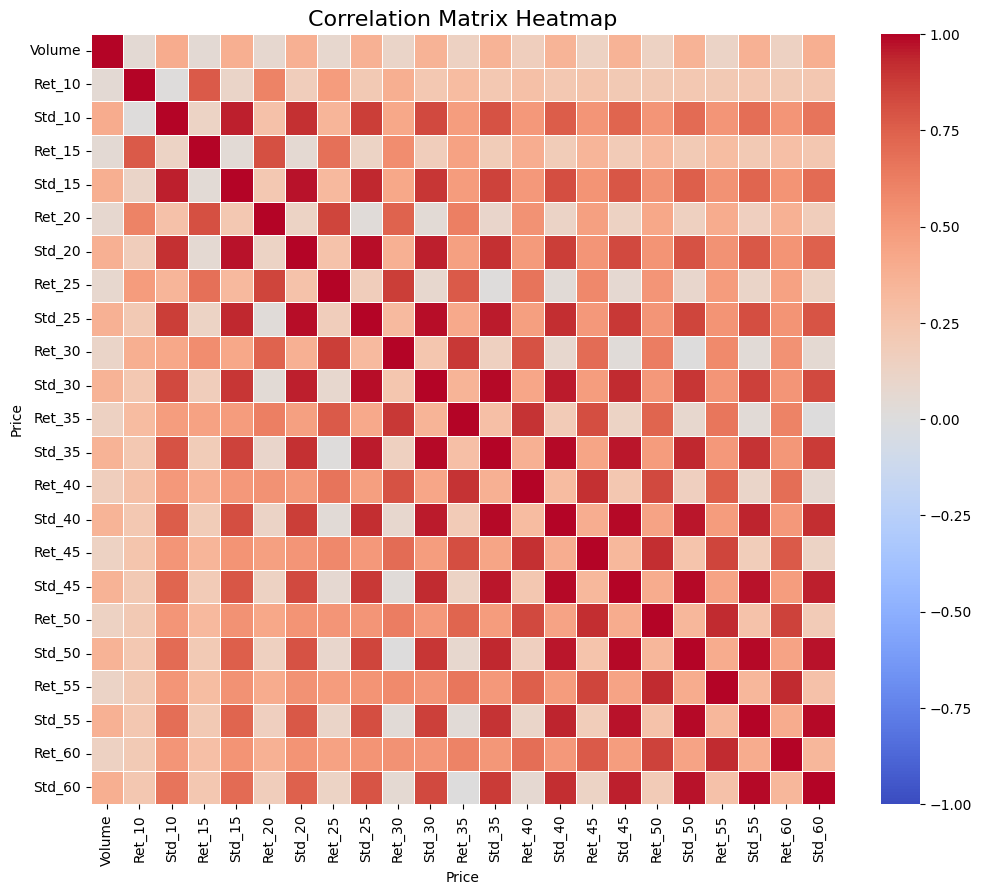

In [16]:
plt.figure(figsize=(12, 10))


sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",      # Color gradient (red is for positive, blue is for negative correlation)
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.show()

In [17]:
X_train_Stage_A = X_train.copy()
X_train_Stage_A.drop(columns=columns_to_drop_1, axis=1, inplace=True)
X_test_Stage_A = X_test.copy()
X_test_Stage_A.drop(columns=columns_to_drop_1, axis=1, inplace=True)

In [18]:
X_train_Stage_A

Price,Volume,Ret_10,Std_10,Ret_15,Ret_20,Ret_25,Ret_30,Ret_35
Date,,,,,,,,
2020-03-30,5751120000,0.107784,0.050520,-0.013770,-0.126621,-0.167042,-0.213103,-0.197413
2020-03-31,6576210000,0.031817,0.047949,-0.079179,-0.114526,-0.152775,-0.226196,-0.220752
2020-04-01,5964000000,0.039505,0.047022,-0.074453,-0.200871,-0.193138,-0.275044,-0.266583
2020-04-02,6464190000,0.057626,0.047402,0.043489,-0.144119,-0.126146,-0.248399,-0.250216
2020-04-03,6096970000,0.085849,0.044928,-0.064519,-0.142203,-0.133045,-0.253018,-0.263723
...,...,...,...,...,...,...,...,...
2024-01-11,3759890000,-0.000104,0.006267,0.002835,0.029451,0.046133,0.048867,0.050530
2024-01-12,3486340000,0.000277,0.006271,0.018270,0.016552,0.050790,0.050564,0.053302
2024-01-16,4260550000,-0.000628,0.006323,0.004238,0.010173,0.039090,0.043049,0.045509


In [19]:
X_test_Stage_A

Price,Volume,Ret_10,Std_10,Ret_15,Ret_20,Ret_25,Ret_30,Ret_35
Date,,,,,,,,
2024-01-19,4287200000,0.031979,0.006751,0.012417,0.015357,0.041973,0.058654,0.061388
2024-01-22,4297610000,0.032347,0.006744,0.014241,0.032235,0.030517,0.064755,0.064529
2024-01-23,3912800000,0.021154,0.005563,0.019989,0.024855,0.030791,0.059708,0.063666
2024-01-24,4330030000,0.023444,0.005445,0.026462,0.024007,0.031679,0.056424,0.058604
2024-01-25,4020430000,0.023038,0.005419,0.039738,0.025036,0.032411,0.057760,0.069273
...,...,...,...,...,...,...,...,...
2024-12-24,1757720000,0.001502,0.011967,-0.000929,0.009499,0.025314,0.007318,0.057037
2024-12-26,2904530000,-0.007070,0.011631,-0.007386,0.003372,0.020945,0.009805,0.044365
2024-12-27,3159610000,-0.012711,0.012016,-0.016572,-0.003883,0.009867,-0.001483,0.008014


2) **Wrapper Method**: Wrapper methods use machine learning model to evaluate subset of features. These methods are compuationally expensive but more powerful than the Filter methods. <br><br>
The specific type of wrapper method we will use here is called Recursive Feature Elimination with Cross Validation(**RFECV**). This method recursively removes weakest feature at each step and uses cross validation to identify the optimal set of features. 'TimeSeriesSplit' with 5 folds was used as the cross validation strategy, which is critical for financial time series data as it preserves temporal order and prevents data leakage by always training on past data and testing on future data. ROC-AUC was is used as the scoring metric.

In [20]:
xgb_wrapper = XGBClassifier(n_estimators=100, random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

wrapper_selector  = RFECV(
    estimator=xgb_wrapper,
    step=1,
    cv=tscv,
    scoring='roc_auc'
)

wrapper_selector.fit(X_train_Stage_A, Y_train)

remaining_features_2 = X_train_Stage_A.columns[wrapper_selector.get_support()]

columns_to_drop_2 = [col for col in X_train_Stage_A.columns if col not in (remaining_features_2)]
print(f"\n No. of features dropped after Stage 2: {len(columns_to_drop_2)} \n List of features dropped after Stage 2: {columns_to_drop_2}")
print(f"\n No. of features retained after Stage 2: {len(X_train_Stage_A.columns)-len(columns_to_drop_2)} \n List of features retained after Stage 2: {remaining_features_2}")


 No. of features dropped after Stage 2: 1 
 List of features dropped after Stage 2: ['Ret_30']

 No. of features retained after Stage 2: 7 
 List of features retained after Stage 2: Index(['Volume', 'Ret_10', 'Std_10', 'Ret_15', 'Ret_20', 'Ret_25', 'Ret_35'], dtype='object', name='Price')


In [21]:
X_train_Stage_B = pd.DataFrame(wrapper_selector.transform(X_train_Stage_A), columns=remaining_features_2)
X_train_Stage_B

Price,Volume,Ret_10,Std_10,Ret_15,Ret_20,Ret_25,Ret_35
0,5.751120e+09,0.107784,0.050520,-0.013770,-0.126621,-0.167042,-0.197413
1,6.576210e+09,0.031817,0.047949,-0.079179,-0.114526,-0.152775,-0.220752
2,5.964000e+09,0.039505,0.047022,-0.074453,-0.200871,-0.193138,-0.266583
3,6.464190e+09,0.057626,0.047402,0.043489,-0.144119,-0.126146,-0.250216
4,6.096970e+09,0.085849,0.044928,-0.064519,-0.142203,-0.133045,-0.263723
...,...,...,...,...,...,...,...
953,3.759890e+09,-0.000104,0.006267,0.002835,0.029451,0.046133,0.050530
954,3.486340e+09,0.000277,0.006271,0.018270,0.016552,0.050790,0.053302
955,4.260550e+09,-0.000628,0.006323,0.004238,0.010173,0.039090,0.045509
956,3.928600e+09,-0.000585,0.006318,-0.003039,0.004633,0.029378,0.039296


In [22]:
X_test_Stage_B = pd.DataFrame(wrapper_selector.transform(X_test_Stage_A), columns=remaining_features_2)
X_test_Stage_B

Price,Volume,Ret_10,Std_10,Ret_15,Ret_20,Ret_25,Ret_35
0,4.287200e+09,0.031979,0.006751,0.012417,0.015357,0.041973,0.061388
1,4.297610e+09,0.032347,0.006744,0.014241,0.032235,0.030517,0.064529
2,3.912800e+09,0.021154,0.005563,0.019989,0.024855,0.030791,0.063666
3,4.330030e+09,0.023444,0.005445,0.026462,0.024007,0.031679,0.058604
4,4.020430e+09,0.023038,0.005419,0.039738,0.025036,0.032411,0.069273
...,...,...,...,...,...,...,...
235,1.757720e+09,0.001502,0.011967,-0.000929,0.009499,0.025314,0.057037
236,2.904530e+09,-0.007070,0.011631,-0.007386,0.003372,0.020945,0.044365
237,3.159610e+09,-0.012711,0.012016,-0.016572,-0.003883,0.009867,0.008014
238,3.433250e+09,-0.023387,0.012362,-0.029770,-0.020193,-0.006176,-0.010120


3) **Embedded Method**: Embeded Method perform feature selection as part of model training process itself. They are more efficient than wrapper methods. <br> <br>
'SelectFromModel' was used with XGBClassifier with median importance threshold. Feature importance get computed basis a gain metric i.e the average improvment in loss brought by feature across all splits. Features of below median importance are dropped.

In [23]:
xgb_embed = XGBClassifier(n_estimators=100, random_state=42)
embed_selector = SelectFromModel(xgb_embed, threshold='median')
embed_selector.fit(X_train_Stage_B, Y_train)

remaining_features_3 = X_train_Stage_B.columns[embed_selector.get_support()]
remaining_features_3

columns_to_drop_3 = [col for col in X_train_Stage_B.columns if col not in (remaining_features_3)]
print(f"\n No. of features dropped after Stage 3: {len(columns_to_drop_3)} \n List of features dropped after Stage 3: {columns_to_drop_3}")
print(f"\n No. of features retained after Stage 3: {len(X_train_Stage_B.columns)-len(columns_to_drop_3)} \n List of features retained after Stage 3: {remaining_features_3}")


 No. of features dropped after Stage 3: 3 
 List of features dropped after Stage 3: ['Ret_10', 'Std_10', 'Ret_20']

 No. of features retained after Stage 3: 4 
 List of features retained after Stage 3: Index(['Volume', 'Ret_15', 'Ret_25', 'Ret_35'], dtype='object', name='Price')


In [24]:
X_train_Stage_C = pd.DataFrame(embed_selector.transform(X_train_Stage_B), columns=remaining_features_3)
X_train_Stage_C

Price,Volume,Ret_15,Ret_25,Ret_35
0,5.751120e+09,-0.013770,-0.167042,-0.197413
1,6.576210e+09,-0.079179,-0.152775,-0.220752
2,5.964000e+09,-0.074453,-0.193138,-0.266583
3,6.464190e+09,0.043489,-0.126146,-0.250216
4,6.096970e+09,-0.064519,-0.133045,-0.263723
...,...,...,...,...
953,3.759890e+09,0.002835,0.046133,0.050530
954,3.486340e+09,0.018270,0.050790,0.053302
955,4.260550e+09,0.004238,0.039090,0.045509
956,3.928600e+09,-0.003039,0.029378,0.039296


In [25]:
X_test_Stage_C = pd.DataFrame(embed_selector.transform(X_test_Stage_B), columns=remaining_features_3)
X_test_Stage_C

Price,Volume,Ret_15,Ret_25,Ret_35
0,4.287200e+09,0.012417,0.041973,0.061388
1,4.297610e+09,0.014241,0.030517,0.064529
2,3.912800e+09,0.019989,0.030791,0.063666
3,4.330030e+09,0.026462,0.031679,0.058604
4,4.020430e+09,0.039738,0.032411,0.069273
...,...,...,...,...
235,1.757720e+09,-0.000929,0.025314,0.057037
236,2.904530e+09,-0.007386,0.020945,0.044365
237,3.159610e+09,-0.016572,0.009867,0.008014
238,3.433250e+09,-0.029770,-0.006176,-0.010120


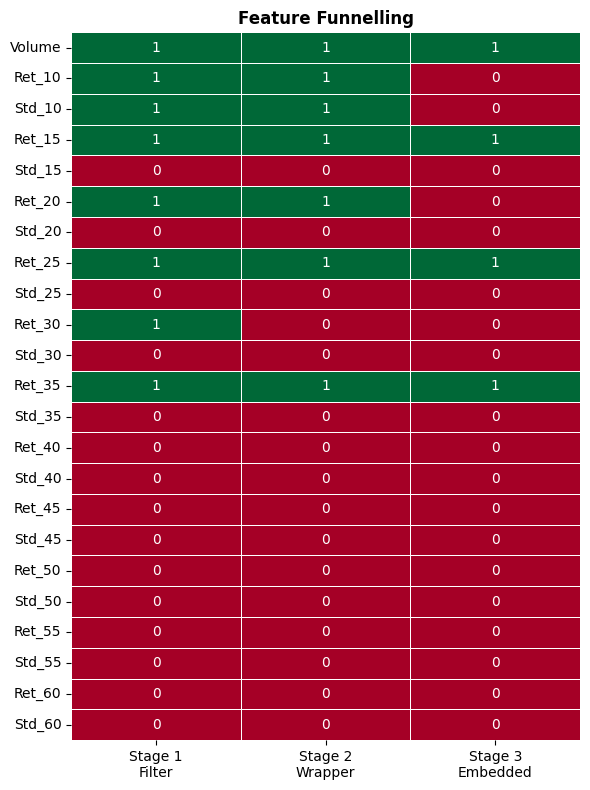

In [26]:
all_features = list(X_train.columns)

grid = pd.DataFrame({
    'Stage 1\nFilter'   : [1 if f in remaining_features_1 else 0 for f in all_features],
    'Stage 2\nWrapper'  : [1 if f in list(remaining_features_2) else 0 for f in all_features],
    'Stage 3\nEmbedded' : [1 if f in list(remaining_features_3) else 0 for f in all_features]
}, index=all_features)

plt.figure(figsize=(6, 8))
sns.heatmap(grid,
            cmap ='RdYlGn',
            linewidths = 0.5,
            linecolor = 'white',
            cbar = False,
            annot = True,
            fmt='d')

plt.title('Feature Funnelling', fontweight='bold', fontsize = 12)
plt.tight_layout()
plt.show()

#### List of Selected Features

The funnelling approach progressively reduced the initial 23 features
to a final set of 4 features as shown below:

| Stage | Method | Features Pre Selection | Features Post Selection |
|---|---|---|---|
| Initial | All engineered features | 23 | 23 |
| Stage 1 | Filter — Correlation (threshold=0.9) | 23 | 8 |
| Stage 2 | Wrapper — RFECV (TimeSeriesSplit) | 8 | 7 |
| Stage 3 | Embedded — SelectFromModel (median) | 7 | 4 |

**Final 4 selected features:**

| SNo | Feature | Description |
|---|---|---|
| 1 | Volume | Measures market participation and conviction |
| 2 | Ret_15 | 15-day rolling return — captures short term momentum |
| 3 | Ret_25 | 25-day rolling return — captures medium term momentum |
| 4 | Ret_35 | 35-day rolling return — captures intermediate term momentum |

The combination of volume and multi-horizon momentum features
provides a robust signal for predicting S&P 500 uptrends. Volume
confirms the strength of price moves while rolling returns at
different windows capture momentum persistence — a well established
predictor in quantitative finance.

**Modelling**<br>
###**Model Building, Tuning and Evaluation**<br><br>


**XGBOOST** (Extreme Gradient Boosting) is a type of gradient boosting method. It is an ensemble learning method which build trees sequentially and each tree reduces the errors of previous tree. It is minimizing the loss function by using gradient descent.

Advantages of using XGBOOOST:


*   It handles class imbalance via sample weights.
*   It natively handles the missing values.
*   It has built in regularization parameters like lambda and gamma to reduce overfitting.




###**a. Base Model**

**Model Fitting**

In [27]:
# Fit the base classifier model

# For binary or multiclass classification
sample_weights = compute_sample_weight(class_weight = 'balanced', y = Y_train)
# 'balanced' will address the moderate imbalance I have mentioned above.

base_model = XGBClassifier(
    verbosity = 0,
    eval_metric = 'logloss',
    random_state=42
)

base_model.fit(
    X_train_Stage_C,
    Y_train,
    sample_weight = sample_weights
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

**Predict Model**

In [28]:
# Predicting the test dataset
Y_pred = base_model.predict(X_test_Stage_C)

# Predict Probabilities
Y_proba = base_model.predict_proba(X_test_Stage_C)

In [29]:
# Accuracy Scores
acc_train = accuracy_score(Y_train, base_model.predict(X_train_Stage_C))
acc_test = accuracy_score(Y_test, Y_pred)

print(f'Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}')

Train Accuracy: 1.0, Test Accuracy: 0.5667


The above output of 100% Train Accuracy shows severe overfitting (the model memorizes the relationship). As we go further we will reduce it through Hyper Parameter tuning.

In [30]:
# Balanced Accuracy Scores
bal_acc_train = balanced_accuracy_score(Y_train, base_model.predict(X_train_Stage_C))
bal_acc_test = balanced_accuracy_score(Y_test,Y_pred)

print(f'Train Balanced Accuracy: {bal_acc_train:0.4}, Test Balanced Accuracy: {bal_acc_test:0.4}')

Train Balanced Accuracy: 1.0, Test Balanced Accuracy: 0.544


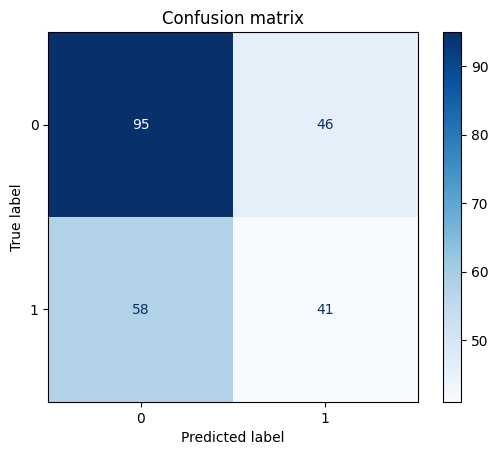

In [31]:
# Display confussion matrix
disp_cm = ConfusionMatrixDisplay.from_estimator(
        base_model,
        X_test_Stage_C,
        Y_test,
        display_labels = base_model.classes_,
        cmap=plt.cm.Blues
    )
disp_cm.ax_.set_title('Confusion matrix')
plt.show()

In [32]:
# Classification Report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.62      0.67      0.65       141
           1       0.47      0.41      0.44        99

    accuracy                           0.57       240
   macro avg       0.55      0.54      0.54       240
weighted avg       0.56      0.57      0.56       240



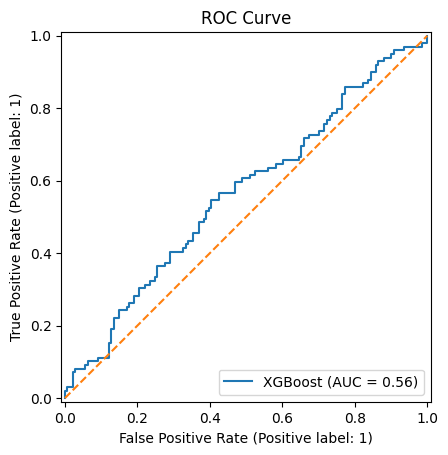

In [33]:
# Display ROCCurve
disp_roc = RocCurveDisplay.from_estimator(
            base_model,
            X_test_Stage_C,
            Y_test,
            name='XGBoost')

disp_roc.ax_.set_title('ROC Curve')
plt.plot([0,1], [0,1], linestyle = '--')
plt.show()

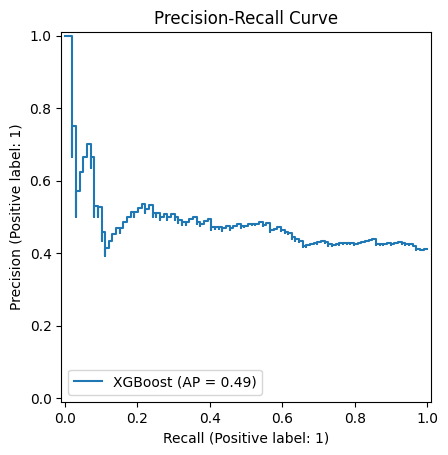

In [34]:
# Display PR Curve
disp_pr = PrecisionRecallDisplay.from_estimator(
    base_model,
    X_test_Stage_C,
    Y_test,
    name = 'XGBoost')

disp_pr.ax_.set_title('Precision-Recall Curve')
plt.show()

###**b. Hyperparameter Tuning**

In [35]:
parameters = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
    'max_depth': [3, 4, 5, 6, 8, 10, 12, 15],
    'min_child_weight': [1, 3, 5, 7],
    'gamma' : [0.0, 0.1, 0.2, 0.3, 0.4],
    'colsample_bytree': [0.3, 0.4, 0.5, 0.7],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(
    estimator = XGBClassifier(
        verbosity = 0,
        eval_metric = 'logloss',
        random_state = 42
    ),
    param_distributions = parameters,
    n_iter = 50,
    cv = TimeSeriesSplit(n_splits = 5),
    scoring = 'roc_auc',
    verbose = 1,
    random_state = 42
)

random_search.fit(
    X_train_Stage_C,
    Y_train,
    sample_weight = compute_sample_weight(class_weight = 'balanced', y = Y_train)
)

print("Best Parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", round(random_search.best_score_, 4))




Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'reg_lambda': 1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.3, 'gamma': 0.4, 'colsample_bytree': 0.3}
Best CV ROC-AUC: 0.55


**Model Fitting with Best Parameters**

In [36]:
print(random_search.best_params_)

{'reg_lambda': 1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.3, 'gamma': 0.4, 'colsample_bytree': 0.3}


In [37]:
best_model = XGBClassifier(
    n_estimators = random_search.best_params_['n_estimators'],
    learning_rate = random_search.best_params_['learning_rate'],
    max_depth = random_search.best_params_['max_depth'],
    min_child_weight = random_search.best_params_['min_child_weight'],
    gamma = random_search.best_params_['gamma'],
    colsample_bytree = random_search.best_params_['colsample_bytree'],
    reg_lambda = random_search.best_params_['reg_lambda'],
    random_state = 42,
    verbosity=0,
    eval_metric='logloss'
)

best_model.fit(
    X_train_Stage_C,
    Y_train,
    sample_weight = compute_sample_weight(class_weight = 'balanced', y = Y_train)
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.3, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.4,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

**Predicting with Best Parameters**

In [38]:
# Predicting the test dataset
Y_pred_best = best_model.predict(X_test_Stage_C)

# Predict Probabilities
Y_proba_best = best_model.predict_proba(X_test_Stage_C)

In [39]:
# Accuracy Scores
acc_train = accuracy_score(Y_train, best_model.predict(X_train_Stage_C))
acc_test = accuracy_score(Y_test, Y_pred_best)

print(f'Train Accuracy: {acc_train:0.4}, Test Accuracy: {acc_test:0.4}')

Train Accuracy: 0.7589, Test Accuracy: 0.575


In [40]:
# Balanced Accuracy Scores
bal_acc_train = balanced_accuracy_score(Y_train, best_model.predict(X_train_Stage_C))
bal_acc_test = balanced_accuracy_score(Y_test,Y_pred_best)

print(f'Train Balanced Accuracy: {bal_acc_train:0.4}, Test Balanced Accuracy: {bal_acc_test:0.4}')

Train Balanced Accuracy: 0.7602, Test Balanced Accuracy: 0.5706


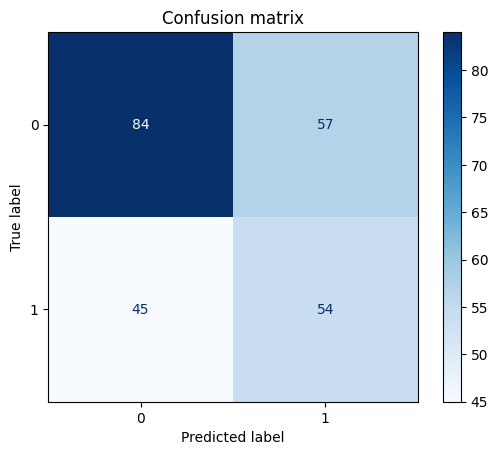

In [41]:
# Display confussion matrix
disp_cm = ConfusionMatrixDisplay.from_estimator(
        best_model,
        X_test_Stage_C,
        Y_test,
        display_labels = base_model.classes_,
        cmap=plt.cm.Blues
    )
disp_cm.ax_.set_title('Confusion matrix')
plt.show()

In [42]:
# Classification Report
print(classification_report(Y_test, Y_pred_best))

              precision    recall  f1-score   support

           0       0.65      0.60      0.62       141
           1       0.49      0.55      0.51        99

    accuracy                           0.57       240
   macro avg       0.57      0.57      0.57       240
weighted avg       0.58      0.57      0.58       240



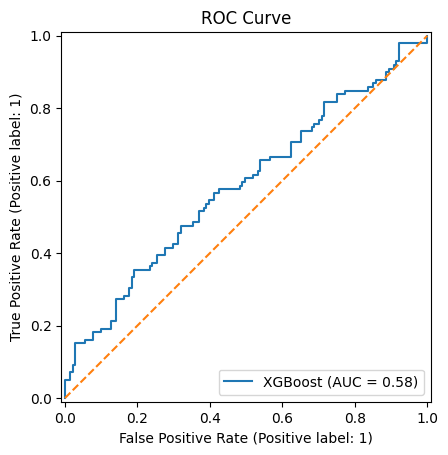

In [43]:
# Display ROCCurve
disp_roc = RocCurveDisplay.from_estimator(
            best_model,
            X_test_Stage_C,
            Y_test,
            name='XGBoost')

disp_roc.ax_.set_title('ROC Curve')
plt.plot([0,1], [0,1], linestyle = '--')
plt.show()

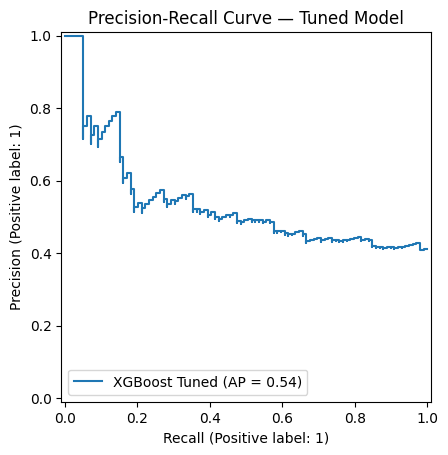

In [44]:
disp_pr = PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test_Stage_C,
    Y_test,
    name='XGBoost Tuned')
disp_pr.ax_.set_title('Precision-Recall Curve — Tuned Model')
plt.show()


###**c. Evaluation**

Below are  the key evaluation metrics (part of **Classification Report**) basis which we evaluate the performance of our model:

- **Precision** - Indicates the proportion of positive identifications (model predicted class 1) which were actually correct. A model which produces no false positives has a precision of 1.0.
$$Precision = \frac{TP}{TP + FP}$$
<br><br>

- **Recall/ Sensitivity** - Indicates the proportion of actual positives which were correctly classified as positives. A model which produces no false negatives has a recall of 1.0.
$$Recall = \frac{TP}{TP + FN}$$
<br><br>

- **Specificity** - Indicates the proportion of actual negatives which were correctly classified as negatives. A model which produces no false positives has a specificity of 1.0.
$$Specificity = \frac{TN}{TN + FP}$$
<br><br>

- **F1 score** - A harmonic mean of precision and recall, a measure that help combine the two. A perfect model achieves an F1 score of 1.0.
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
<br><br>

- **Support** - The number of samples each metric was calculated on.
<br><br>

- **Accuracy** - Proportion of correct classification as a ratio of total classifications. Perfect accuracy is equal to 1.0.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
<br><br>

- **Balanced Accuracy** - It is the average of the correctly predicted proportions for each class independently.
$$Balanced\ Accuracy = \frac{Sensitivity + Specificity}{2}$$
<br><br>

- **Macro avg** - The average of precision, recall and F1 score between classes. Macro avg doesn't take class imbalance into account, so if we have class imbalances, we need to pay attention to this metric.
<br><br>

- **Weighted avg** - The weighted average of precision, recall and F1 score between classes. Weighted means each metric is calculated with respect to how many samples there are in each class. This metric will favour the majority class (e.g. will give a high value when one class out performs another due to having more samples).
<br><br>

Note:<br>
TP - True Positives <br>
FP - False Positives (Type I Error) <br>
TN - True Negatives <br>
FN - False Negatives (Type II Error)<br><br>


**Key Takeaways**:

1) The Tuned Model achieve Recall/ Sensitivity Score of **0.60** for Downtrend and **0.55** for Uptrend.

2) The Tuned Model achieved Precision of **0.65** for Downtrend and **0.49** for Uptrend.

3) The Macro Average Score showed improvement from **0.55** (Precision) & **0.54** (Recall) for Base Model to **0.57** (Precision as well as Recall) for Tuned Model, is showing a general improvement in Predictive power of model due to tuning.

4) As the f1-score is the harmonic mean of precision and recall, the imporvement in Macro Average of f1-score from **0.54** for Base Model to **0.57** for Tuned Model supports point 3 above.
5) The tuned model achieved a ROC-AUC of **0.58** on the
test set, compared to **0.56** for the base
model, this confirms that hyperparameter tuning improved
the model's discriminatory power.


Note: - **ROC-AUC** - ROC stands for Receiver Operator Charachteristic graph. It plots True Positive rate i.e. Recall or Sensitivity against the False Positive rate i.e. (1 - Specificity) as we vary the threshold. AUC i.e. Area Undee the Curve is the area between this curve (ROC) and x-axis.
<br><br>


Below is the comparison of Parameters between the Base Model and Best Model:

This help explains how the hyperparamter tuning has led to reduction in overfitting indicated by the Train Accuracy reducing from 100 % for Base Model to 75.89 % for Best Model, while the Test Accuracy increasing from 56.67 % for Base Model to 57.50% for Best Model.

**Best Parameters Found by RandomizedSearchCV**

| Parameter | Base Model (Default) | Best Model (Tuned) |
|---|---|---|
| n_estimators | 100 | 100 |
| learning_rate | 0.3 | 0.3 |
| max_depth | 6 | 5 |
| min_child_weight | 1 | 3 |
| gamma | 0 | 0.4 |
| colsample_bytree | 1 | 0.3 |
| reg_lambda | 1 | 1 |

<br><br>
Note: The base model was initialised with XGBoost default parameters.Parameters displayed as None indicate that XGBoost uses its internal defaults at runtime.

In [45]:
print("=" * 55)
print("          MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"  Base Model  — Train Accuracy     : {accuracy_score(Y_train, base_model.predict(X_train_Stage_C)):.4f}")
print(f"  Base Model  — Test  Accuracy     : {accuracy_score(Y_test, Y_pred):.4f}")
print(f"  Base Model  — Balanced Test Accuracy  : {balanced_accuracy_score(Y_test, Y_pred):.4f}")
print("-" * 55)
print(f"  Tuned Model — Train Accuracy     : {accuracy_score(Y_train, best_model.predict(X_train_Stage_C)):.4f}")
print(f"  Tuned Model — Test  Accuracy     : {accuracy_score(Y_test, Y_pred_best):.4f}")
print(f"  Tuned Model — Balanced Test Accuracy  : {balanced_accuracy_score(Y_test, Y_pred_best):.4f}")
print("=" * 55)

          MODEL COMPARISON SUMMARY
  Base Model  — Train Accuracy     : 1.0000
  Base Model  — Test  Accuracy     : 0.5667
  Base Model  — Balanced Test Accuracy  : 0.5440
-------------------------------------------------------
  Tuned Model — Train Accuracy     : 0.7589
  Tuned Model — Test  Accuracy     : 0.5750
  Tuned Model — Balanced Test Accuracy  : 0.5706


##**Conclusion**

The XGBoost model was developed to predict positive market moves
(uptrend) on the S&P 500 index using 5 years of daily price data
from 2020 to 2025.

The funnelling feature selection approach reduced the initial 23
features to 4 final features: Volume, Ret_15, Ret_25 and Ret_35.
These features capture market participation and momentum across
multiple time horizons, which are well established predictors in
quantitative finance.

The base model achieved a test accuracy of 56.67 % and balanced
accuracy of 54.40 %. After hyperparameter tuning using
RandomizedSearchCV with TimeSeriesSplit cross validation, the
optimised model achieved a test accuracy of 57.50 % and balanced
accuracy of 57.06 %, demonstrating improvement over the baseline.

The ROC-AUC score of 0.58 (i.e 58 %) post Hyperparameter tuning indicates above random discriminatory power of the model. Predicting short term market moves remains inherently challenging due to market noise, however the model demonstrates statistically meaningful predictive ability above random chance of 50:50.

The confusion matrix of the tuned model shows stronger specificity (59.57 %) than sensitivity (54.54 %), indicating the model is more conservative — better at identifying non-uptrend days than capturing uptrend ones.

####**Backtesting**

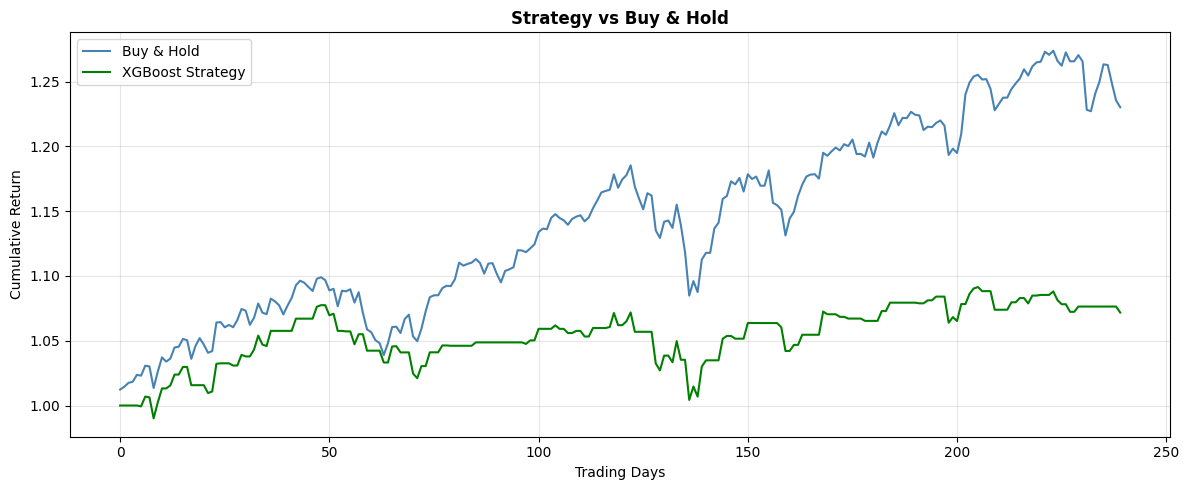

     BACKTESTING SUMMARY
  Buy & Hold Return : 23.02%
  XGBOOST Return    : 7.18%
  Sharpe Ratio      : 0.8123


In [46]:
# Getting actual market returns for test period (Buy and Hold Strategy)
market_returns = data.loc[X_test.index, 'Return']

# XGBOOST Strategy return: i.e earn return when signal=1, else 0
xgboost_returns = market_returns * Y_pred_best

# Calcualting the Cumulative returns
cum_market   = (1 + market_returns).cumprod()
cum_xgboost = (1 + xgboost_returns).cumprod()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(cum_market.values,   label='Buy & Hold', color='steelblue')
plt.plot(cum_xgboost.values, label='XGBoost Strategy', color='green')
plt.title('Strategy vs Buy & Hold', fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary Table
print("=" * 45)
print("     BACKTESTING SUMMARY")
print("=" * 45)
print(f"  Buy & Hold Return : {cum_market.iloc[-1]-1:.2%}")
print(f"  XGBOOST Return    : {cum_xgboost.iloc[-1]-1:.2%}")
print(f"  Sharpe Ratio      : {(xgboost_returns.mean()/xgboost_returns.std())*np.sqrt(252):.4f}")
print("=" * 45)

As can be seen above XGBOOST Startegy fell behind the Buy & Hold Startegy. Our startegy may work better in case of bear run when compared to bull run.

**References**

1) CQF Module 4 Lecture - Decision Trees & Ensemble Models By Dr. Panos Parpas
2) CQF Module 4 Python Labs - Gradient Boosting for Price Prediction By Mr Kannan Singaravelu
3) Youtube Machine Learning Playlist - StatQuest with Mr Josh Starmer
4) Youtube Machine Learning Playlist - CampusX by Nitish Singh